# PT-Flow on CIFAR-10 — Kaggle T4 x2

Downloads the repo and CIFAR-10 from Google Drive, trains PT-Flow across both T4s,
saves the checkpoint, and generates images from it. **Resumable** — point
`RESUME_CKPT_PATH` or `RESUME_GDRIVE_ID` in cell [1] at an earlier
`state_XXXXXXXX.pt` and set `TOTAL_STEPS` to the target step.

**What this is and is not.** A thousand-step block is a *pipeline* run: it proves
the graft trains, the ESS monitor certifies, `lambda_prox` lifts off zero, the
checkpoint round-trips, and all three samplers produce images. It is not a quality
run — the paper's numbers are ImageNet-256 latents at 30k–200k steps on 8 nodes.
Expect colour-blob samples for a long while, and read the *metrics*, not the
pictures.

**Three deviations from the repo's own configs, all forced by the hardware:**

| Repo config | Here | Why |
|---|---|---|
| SD-VAE latents, 32×32×4 | raw pixels, 32×32×3 | CIFAR-10 is already 32×32; an 8× VAE downsample of a 32px image leaves 4×4 |
| MAE feature extractor (`hf://mae_latent_256`) | `global` feature only (flattened pixels) | the MAE is trained on 256-res latents and does not exist for this space. The drift loss still runs — on raw pixels, which is a weaker signal. See `USE_CONVNEXT` in cell [1]. |
| `use_bf16: true` | `false` | T4 is Turing (sm_75). No bf16. |

FID evaluation is switched off: `utils/fid_util._canonical_dataset_name` accepts
`imagenet256` only, and the reference `.npz` does not exist for CIFAR.

## [1] Knobs — edit here, nothing below

In [1]:
# ---- Google Drive file ids -------------------------------------------------
REPO_GDRIVE_ID  = "1S8SsNAE6AqQ_QHSTYQJTuZ6gdNhyAixR"   # zipped W-Flow-main folder
CIFAR_GDRIVE_ID = "1AMESa9etn7VmnXb3GPbO2DWYttULbRvY"   # official CIFAR-10

# ---- Paths on Kaggle -------------------------------------------------------
WORK     = "/kaggle/working/ptflow"          # the repo, copied here so it is writable
DATA     = "/kaggle/working/data/cifar10"    # ImageFolder: {train,val}/<k>_<name>/*.png
RUNDIR   = "/kaggle/working/runs/ptflow_cifar10"
DOWNLOAD = "/kaggle/working/_downloads"

# ---- Run size --------------------------------------------------------------
# TOTAL_STEPS is the TARGET step, not a number of extra steps.  Resuming a
# step-1000 checkpoint with TOTAL_STEPS = 2000 runs steps 1001..2000.
TOTAL_STEPS   = 10000
SAVE_PER_STEP = 500
NPROC         = 2        # both T4s.  Set 1 to debug on one GPU.

# ---- Resume ----------------------------------------------------------------
# Leave both empty for a fresh run.  To continue an earlier run, point ONE of
# these at its state_XXXXXXXX.pt (or a .zip wrapping one).
#
# The MODEL KNOBS BELOW MUST NOT CHANGE across a resume -- restore_checkpoint
# loads with strict=True.  Cell [7] checks that for you before launching.
RESUME_CKPT_PATH = "/kaggle/input/datasets/khan1803115/pt-flow-cifar10-checkpoint/state_00001000.pt"    # e.g. "/kaggle/input/ptflow-ckpt/state_00001000.pt"
RESUME_GDRIVE_ID = ""    # e.g. "1AbC..."   a Drive file id
PUSH_AT_RESUME   = 20    # memory-bank refill on the resume step, in units of
                         # push_per_step.  train_gen defaults to 3000, i.e. it
                         # would stream ~384k images before step 1001 begins --
                         # 600x more than the bank holds.  20 fills it over.

# ---- Model (pixel space, 32x32x3) -----------------------------------------
HIDDEN = 384   # cond_dim is pinned to this: LightningDiTBlock builds its adaLN as
DEPTH  = 8     # Linear(hidden, 6*hidden) and so silently requires
HEADS  = 6     # cond_dim == hidden_size for the *generator*.
PATCH  = 2     # 32/2 = 16 -> 256 tokens

# ---- Batch shape -----------------------------------------------------------
TRAIN_BSZ      = 16      # labels per optimizer step, summed over GPUs
GEN_PER_LABEL  = 16      # generated samples per label -- the OT batch
POS_PER_SAMPLE = 16
NEG_PER_SAMPLE = 8
GRAD_ACCUM     = 2
LOADER_BSZ     = 256     # dataloader batch, summed over GPUs
NUM_WORKERS    = 2       # per rank; Kaggle gives 4 vCPU

# ---- PT-Flow ---------------------------------------------------------------
PT_ENABLED      = True
LAMBDA_PROX_MAX = 0.3
PROX_WARMUP     = 150    # pure W-Flow until here.  Scaled down from the repo's
PROX_RAMP       = 350    # 5000/15000 for a 1000-step run.
EPS_MAX, EPS_MIN = 0.2, 0.005
EPS_ANNEAL       = 600

# ---- Feature extractor -----------------------------------------------------
# False -> the drift loss sees only the "global" feature: the flattened image.
#          Fully offline, fast.
# True  -> ConvNeXtV2-base from HuggingFace (~350 MB, needs internet).  It
#          upsamples every image to 224x224 internally, and the generated branch
#          needs gradients through it, so expect several times the step time.
#          Better features, materially slower.  Raise the step budget with it.
USE_CONVNEXT = False

NUM_CLASSES = 10
CIFAR_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

import os
for d in (DOWNLOAD, os.path.dirname(DATA), os.path.dirname(RUNDIR)):
    os.makedirs(d, exist_ok=True)
print("knobs set")

knobs set


## [2] Environment

In [2]:
import subprocess, sys, torch

# Kaggle already ships torch / torchvision / numpy / scipy / PIL / tqdm / pyyaml.
# These are what the repo adds on top, and they are small.
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "einops", "absl-py", "gdown"], check=True)
if USE_CONVNEXT:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers"], check=True)

print("torch    ", torch.__version__)
print("cuda     ", torch.cuda.is_available())
n = torch.cuda.device_count()
print("gpu count", n)
for i in range(n):
    p = torch.cuda.get_device_properties(i)
    print(f"  [{i}] {p.name}  {p.total_memory / 2**30:.1f} GiB  sm_{p.major}{p.minor}"
          + ("   <- no bf16" if p.major < 8 else ""))
if n < NPROC:
    print(f"\n!! Only {n} GPU(s) visible but NPROC={NPROC}.")
    print("   Kaggle: Settings -> Accelerator -> GPU T4 x2, then re-run.")

torch     2.10.0+cu128
cuda      True
gpu count 2
  [0] Tesla T4  14.6 GiB  sm_75   <- no bf16
  [1] Tesla T4  14.6 GiB  sm_75   <- no bf16


## [3] Repo from Drive

In [3]:
import os, sys, shutil, zipfile, tarfile, glob

def gdrive_download(file_id, dest):
    if os.path.exists(dest) and os.path.getsize(dest) > 1024:
        print("cached:", dest, f"{os.path.getsize(dest) / 2**20:.1f} MiB")
        return dest
    import gdown
    gdown.download(id=file_id, output=dest, quiet=False)
    if not os.path.exists(dest):
        raise SystemExit(
            "Drive download failed.  Kaggle needs internet ON "
            "(Settings -> Internet -> On; requires a phone-verified account).\n"
            "Offline alternative: upload the archive as a Kaggle Dataset and point "
            "the paths at /kaggle/input/<your-dataset>/.")
    print(f"{dest}  {os.path.getsize(dest) / 2**20:.1f} MiB")
    return dest

def unpack(path, dest, depth=0):
    """zip or tar, plus one level of nesting (a .zip holding a .tar.gz)."""
    os.makedirs(dest, exist_ok=True)
    with open(path, "rb") as f:
        magic = f.read(4)
    if magic[:2] == b"PK":
        with zipfile.ZipFile(path) as z:
            z.extractall(dest)
    elif magic[:2] == b"\x1f\x8b" or tarfile.is_tarfile(path):
        with tarfile.open(path) as t:
            try:
                t.extractall(dest, filter="data")     # python >= 3.12
            except TypeError:
                t.extractall(dest)
    else:
        raise ValueError(f"{path}: neither zip nor tar (magic {magic!r})")
    if depth == 0:
        inner = (glob.glob(os.path.join(dest, "**", "*.tar.gz"), recursive=True)
                 + glob.glob(os.path.join(dest, "**", "*.tgz"), recursive=True)
                 + glob.glob(os.path.join(dest, "**", "*.tar"), recursive=True))
        for f in inner:
            unpack(f, os.path.dirname(f), depth=1)
    return dest

def find_repo_root(root):
    """The directory that actually holds train.py + pt/ + models/."""
    for dirpath, dirnames, filenames in os.walk(root):
        if "train.py" in filenames and "pt" in dirnames and "models" in dirnames:
            return dirpath
    raise SystemExit(f"No PT-Flow checkout found under {root}")

zip_path = gdrive_download(REPO_GDRIVE_ID, os.path.join(DOWNLOAD, "repo.zip"))
extract  = os.path.join(DOWNLOAD, "repo_extract")
shutil.rmtree(extract, ignore_errors=True)
unpack(zip_path, extract)

src = find_repo_root(extract)
print("repo found at:", src)

shutil.rmtree(WORK, ignore_errors=True)
shutil.copytree(src, WORK)
os.chdir(WORK)
if WORK not in sys.path:
    sys.path.insert(0, WORK)

print("copied to    :", WORK)
print("contents     :", sorted(os.listdir(WORK))[:14], "...")

Downloading...
From: https://drive.google.com/uc?id=1S8SsNAE6AqQ_QHSTYQJTuZ6gdNhyAixR
To: /kaggle/working/_downloads/repo.zip
100%|██████████| 413k/413k [00:00<00:00, 90.8MB/s]

/kaggle/working/_downloads/repo.zip  0.4 MiB
repo found at: /kaggle/working/_downloads/repo_extract/PT-Flow
copied to    : /kaggle/working/ptflow
contents     : ['.gitignore', 'LICENSE', 'README.md', 'README_PTFLOW.md', '__pycache__', 'configs', 'dataset', 'drift_loss.py', 'drift_loss_ot.py', 'examples', 'inference_ours.py', 'install_env.sh', 'memory_bank.py', 'misc'] ...


## [4] CIFAR-10 from Drive → ImageFolder

`dataset/dataset.py` builds a `torchvision.datasets.ImageFolder` over
`IMAGENET_PATH/{train,val}`, so the cheapest way to feed it CIFAR is to decode the
official batches into that layout. Class dirs are named `0_airplane` … `9_truck`,
which sorts alphabetically into the CIFAR label order, so `ImageFolder`'s indices
match the official ones.

Handles the python-pickle release, the binary release, a `.zip` wrapping either,
and an already-extracted ImageFolder.

In [4]:
import os, glob, pickle, numpy as np
from PIL import Image
from concurrent.futures import ThreadPoolExecutor

def _load_meta(root):
    for p in glob.glob(os.path.join(root, "**", "batches.meta"), recursive=True):
        with open(p, "rb") as f:
            d = pickle.load(f, encoding="bytes")
        names = d.get(b"label_names") or d.get("label_names")
        if names:
            return [n.decode() if isinstance(n, bytes) else str(n) for n in names]
    for p in glob.glob(os.path.join(root, "**", "batches.meta.txt"), recursive=True):
        names = [l.strip() for l in open(p) if l.strip()]
        if len(names) == 10:
            return names
    return list(CIFAR_NAMES)

def _read_python(paths):
    xs, ys = [], []
    for p in paths:
        with open(p, "rb") as f:
            d = pickle.load(f, encoding="bytes")
        data = d.get(b"data", d.get("data"))
        lab  = d.get(b"labels", d.get("labels"))
        xs.append(np.asarray(data, np.uint8).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1))
        ys.append(np.asarray(lab, np.int64))
    return np.concatenate(xs), np.concatenate(ys)

def _read_binary(paths):
    xs, ys = [], []
    for p in paths:
        raw = np.fromfile(p, dtype=np.uint8).reshape(-1, 3073)
        ys.append(raw[:, 0].astype(np.int64))
        xs.append(raw[:, 1:].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1))
    return np.concatenate(xs), np.concatenate(ys)

def load_cifar(root):
    g = lambda pat: sorted(glob.glob(os.path.join(root, "**", pat), recursive=True))
    py_tr = [p for p in g("data_batch_*") if not p.endswith(".bin")]
    py_te = [p for p in g("test_batch") if not p.endswith(".bin")]
    bin_tr, bin_te = g("data_batch_*.bin"), g("test_batch.bin")
    if py_tr and py_te:
        print(f"python pickle format: {len(py_tr)} train batches")
        return _read_python(py_tr), _read_python(py_te), _load_meta(root)
    if bin_tr and bin_te:
        print(f"binary format: {len(bin_tr)} train batches")
        return _read_binary(bin_tr), _read_binary(bin_te), _load_meta(root)
    raise SystemExit(
        f"No CIFAR-10 batches under {root}.\n"
        f"Top level: {os.listdir(root)[:20]}\n"
        "Expected data_batch_1..5 + test_batch (python) or *.bin (binary).")

def write_imagefolder(x, y, split, names):
    out  = os.path.join(DATA, split)
    dirs = [os.path.join(out, f"{k}_{names[k]}") for k in range(NUM_CLASSES)]
    for d in dirs:
        os.makedirs(d, exist_ok=True)
    if sum(len(os.listdir(d)) for d in dirs) >= len(x):
        print(f"{split}: already present, skipping")
        return out
    counter, jobs = [0] * NUM_CLASSES, []
    for i in range(len(x)):
        k = int(y[i])
        jobs.append((x[i], os.path.join(dirs[k], f"{counter[k]:05d}.png")))
        counter[k] += 1
    def _w(job):
        arr, path = job
        Image.fromarray(arr).save(path, optimize=False, compress_level=1)
    with ThreadPoolExecutor(max_workers=8) as ex:
        list(ex.map(_w, jobs))
    print(f"{split}: wrote {len(jobs)} PNGs to {out}")
    return out

already = all(len(glob.glob(os.path.join(DATA, s, "*", "*.png"))) > 100
              for s in ("train", "val"))

if already:
    print("ImageFolder already built at", DATA)
else:
    cpath = gdrive_download(CIFAR_GDRIVE_ID, os.path.join(DOWNLOAD, "cifar10.bin"))
    cextr = os.path.join(DOWNLOAD, "cifar_extract")
    if glob.glob(os.path.join(cextr, "**", "*batch*"), recursive=True):
        print("already extracted")
    else:
        unpack(cpath, cextr)
    if glob.glob(os.path.join(cextr, "**", "train", "*", "*.png"), recursive=True):
        # the archive already was an ImageFolder
        import shutil as _sh
        _sh.copytree(os.path.dirname(glob.glob(os.path.join(cextr, "**", "train"),
                                               recursive=True)[0]), DATA, dirs_exist_ok=True)
    else:
        (xtr, ytr), (xte, yte), names = load_cifar(cextr)
        print("train", xtr.shape, "val", xte.shape, "| classes:", names)
        write_imagefolder(xtr, ytr, "train", names)
        write_imagefolder(xte, yte, "val", names)
        CIFAR_NAMES = names

for s in ("train", "val"):
    n = len(glob.glob(os.path.join(DATA, s, "*", "*.png")))
    print(f"{s:>5}: {n} images in {len(os.listdir(os.path.join(DATA, s)))} class dirs")

Downloading...
From (original): https://drive.google.com/uc?id=1AMESa9etn7VmnXb3GPbO2DWYttULbRvY
From (redirected): https://drive.google.com/uc?id=1AMESa9etn7VmnXb3GPbO2DWYttULbRvY&confirm=t&uuid=f55851e1-f723-413c-b570-4a777aaea2a3
To: /kaggle/working/_downloads/cifar10.bin
100%|██████████| 170M/170M [00:03<00:00, 54.0MB/s]


/kaggle/working/_downloads/cifar10.bin  162.6 MiB
python pickle format: 5 train batches
train (50000, 32, 32, 3) val (10000, 32, 32, 3) | classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train: wrote 50000 PNGs to /kaggle/working/data/cifar10/train
val: wrote 10000 PNGs to /kaggle/working/data/cifar10/val
train: 50000 images in 10 class dirs
  val: 10000 images in 10 class dirs


## [5] Point the repo at Kaggle, and switch FID off

Three edits, all in the copied tree at `/kaggle/working/ptflow` — the Drive archive
is untouched.

1. `utils/env.py` — the repo ships `/path/to/...` placeholders.
2. `train.py` — the eval block fires unconditionally at `step == 1` and
   `step == total_steps`, and `utils/fid_util._canonical_dataset_name` raises on
   anything that is not `imagenet256`. Gated behind `PTFLOW_SKIP_EVAL`.
3. `train.py` — the positive memory bank is allocated `num_classes=1000` regardless
   of the dataset. At 32×32×3 that is a 786 MB array per rank to hold 10 classes.
   Gated behind `PTFLOW_NUM_CLASSES`.

Both code patches are no-ops when the env vars are unset, so the tree still behaves
exactly as upstream for an ImageNet run.

In [5]:
import pathlib, textwrap

env_py = pathlib.Path(WORK, "utils", "env.py")
env_py.write_text(textwrap.dedent(f"""\
    from __future__ import annotations

    HF_REPO_ID    = "Goodeat/drifting"
    HF_ROOT       = "/kaggle/working/_hf/drifting"
    VAE_HF_PATH   = "/kaggle/working/_hf/sdvae"
    TORCH_HUB_DIR = "/kaggle/working/_hf/torch_hub"

    WFLOW_HF_REPO_ID = "jiaqihan99/W-Flow"
    WFLOW_HF_ROOT    = "/kaggle/working/_hf/wflow"

    # CIFAR-10 as an ImageFolder, read by dataset.dataset._build_imagenet_dataset.
    IMAGENET_PATH       = {str(DATA)!r}
    IMAGENET_CACHE_PATH = "/kaggle/working/_hf/latent_cache"
    IMAGENET_FID_NPZ    = "/kaggle/working/_hf/fid_stats.npz"
    IMAGENET_PR_NPZ     = ""
    """), encoding="utf-8")
print("wrote", env_py)

tp = pathlib.Path(WORK, "train.py")
s  = tp.read_text(encoding="utf-8")

old_eval = "        if (step % eval_per_step == 0) or (step == 1) or (step == total_steps):"
new_eval = ('        _skip_eval = os.environ.get("PTFLOW_SKIP_EVAL", "0") == "1"\n'
            '        if (not _skip_eval) and ((step % eval_per_step == 0) '
            'or (step == 1) or (step == total_steps)):')
old_bank = ("    memory_bank_positive = ArrayMemoryBank(num_classes=1000, "
            "max_size=positive_bank_size)")
new_bank = ('    _nc = int(os.environ.get("PTFLOW_NUM_CLASSES", "1000"))\n'
            '    memory_bank_positive = ArrayMemoryBank(num_classes=_nc, '
            'max_size=positive_bank_size)')

for old, new, tag in ((old_eval, new_eval, "skip-eval"), (old_bank, new_bank, "num-classes")):
    if new.splitlines()[0] in s:
        print(f"  {tag}: already patched")
    else:
        assert s.count(old) == 1, f"{tag}: expected 1 match, found {s.count(old)}"
        s = s.replace(old, new)
        print(f"  {tag}: patched")
tp.write_text(s, encoding="utf-8")
print("train.py ok")

wrote /kaggle/working/ptflow/utils/env.py
  skip-eval: patched
  num-classes: patched
train.py ok


## [6] The config

In [6]:
import os, pathlib, yaml

assert HIDDEN % HEADS == 0, "hidden_size must divide by num_heads"

cfg = {
  "logging": {"use_wandb": False, "log_every_k": 10},

  "dataset": {
    "resolution": 32,
    "use_aug": False,        # center_crop_arr(32) on a 32px image is a no-op + hflip
    "use_latent": False,     # pixel space: no SD-VAE
    "use_cache": False,
    "num_classes": NUM_CLASSES,
    "batch_size": LOADER_BSZ,
    "eval_batch_size": LOADER_BSZ,
    "kwargs": {"num_workers": NUM_WORKERS, "pin_memory": True, "prefetch_factor": 2},
  },

  "model": {
    "cond_dim": HIDDEN,      # must equal hidden_size for the generator
    "input_size": 32, "in_channels": 3, "out_channels": 3,
    "patch_size": PATCH, "hidden_size": HIDDEN, "depth": DEPTH,
    "num_heads": HEADS, "mlp_ratio": 4.0,
    "use_qknorm": True, "use_swiglu": True, "use_rope": True, "use_rmsnorm": True,
    "n_cls_tokens": 4, "noise_classes": 64, "noise_coords": 32,
    "use_bf16": False,       # T4 is sm_75
    "attn_fp32": True,
    # README_PTFLOW.md, "residual is not a free choice": training from scratch,
    # zero-init final layer => m is the identity at step 0 => the Laplace proposal
    # sits exactly on the prox point => ESS/K = 1.  Only false when resuming a
    # released W-Flow checkpoint, whose weights mean m(x) = net(x).
    "residual": True,
  },

  "optimizer": {
    "lr_schedule": {"learning_rate": 2.0e-4, "warmup_steps": 100,
                    "lr_schedule": "const", "total_steps": TOTAL_STEPS},
    "weight_decay": 0.01, "adam_b1": 0.9, "adam_b2": 0.95,
  },

  "train": {
    "diverse_noise": True,
    "train_batch_size": TRAIN_BSZ,
    "seed": 42,
    "total_steps": TOTAL_STEPS,
    "save_per_step": SAVE_PER_STEP,
    "keep_every": TOTAL_STEPS,
    "keep_last": 2,
    "eval_per_step": 10 ** 9,          # belt; PTFLOW_SKIP_EVAL=1 is the braces
    "pos_per_sample": POS_PER_SAMPLE,
    "neg_per_sample": NEG_PER_SAMPLE,
    "positive_bank_size": 64,
    "negative_bank_size": 512,
    "forward_dict": {"gen_per_label": GEN_PER_LABEL, "cfg_min": 1.0,
                     "cfg_max": 4.0, "neg_cfg_pw": 3.0},
    "activation_kwargs": {},           # these are MAE-only kwargs; no MAE here
    "loss_kwargs": {"R_list": [0.05]},
    "cfg_list": [1.0],
    "ema_decay": 0.999,
    "push_per_step": LOADER_BSZ // max(1, NPROC),
    "push_at_resume": PUSH_AT_RESUME,   # see the note in cell [1]
    "grad_accum_steps": GRAD_ACCUM,
    "ot_mode": "debiased",
    "ot_kwargs": {"sinkhorn_num_iter": 10, "use_new_cfg": True,
                  "disable_diag_mask": True, "resample_neg": True,
                  "batch_sinkhorn": False, "use_quadratic_cost": True},
  },

  "feature": {"use_mae": False, "use_convnext": bool(USE_CONVNEXT),
              "convnext_bf16": False},
}

if PT_ENABLED:
    cfg["pt"] = {
      "enabled": True,
      "K": 8, "noise_bsz": 8, "data_bsz": 16,
      "p_uncond": 0.1, "potential_chunk": 0,
      "prox_max_batch": 32, "prox_mode": "detach", "scale_K": 4,
      "lambda_gauge": 0.1, "lambda_mag": 0.0, "logw_clip": 30.0,
      "max_grad_norm": 1.0, "curv_probe": False, "curv_allow": 0.5,
      "ema_decay": 0.999, "init_generator_from": "",
      "model": {
        "cond_dim": HIDDEN,   # PotentialNet inserts cond_proj when != hidden_size
        "hidden_size": 256, "depth": 6, "num_heads": 4, "patch_size": PATCH,
        "mlp_ratio": 4.0, "use_qknorm": True, "use_swiglu": True,
        "use_rope": True, "use_rmsnorm": True, "n_cls_tokens": 0,
        "use_bf16": False, "attn_fp32": True,
        "phi_scale": None, "quad_anchor": 0.0, "output_mode": "phi",
      },
      "optimizer": {
        "weight_decay": 0.01, "adam_b1": 0.9, "adam_b2": 0.95,
        "lr_schedule": {"learning_rate": 1.0e-4, "warmup_steps": 100,
                        "lr_schedule": "const", "total_steps": TOTAL_STEPS},
      },
      "schedule": {
        "eps_max": EPS_MAX, "eps_min": EPS_MIN,
        "eps_anneal_steps": EPS_ANNEAL, "eps_warmup": 50,
        "alpha_def_start": 0.1, "alpha_def_end": 0.01, "alpha_def_degraded": 0.25,
        "prox_warmup": PROX_WARMUP, "prox_ramp": PROX_RAMP,
        "lambda_prox_max": LAMBDA_PROX_MAX, "prox_decay_on_degrade": 0.999,
        "lambda_scale": 0.1, "lambda_curv": 0.0,
        "theta_period": 1, "theta_period_degraded": 2,
        "ess_healthy": 0.3, "ess_broken": 0.05, "ess_ema_decay": 0.98,
      },
      "scale_model": {
        "cond_dim": HIDDEN,
        "hidden_size": 128, "depth": 3, "num_heads": 4, "patch_size": PATCH,
        "mlp_ratio": 4.0, "use_qknorm": True, "use_swiglu": True,
        "use_rope": True, "use_rmsnorm": True, "n_cls_tokens": 0,
        "use_bf16": False, "attn_fp32": True, "scale_max": 3.0,
      },
      "scale_mode": "learned",
    }

CFG_PATH = os.path.join(WORK, "configs", "gen", "ptflow_cifar10_kaggle.yaml")
pathlib.Path(CFG_PATH).write_text(yaml.safe_dump(cfg, sort_keys=False), encoding="utf-8")
print("wrote", CFG_PATH, "\n")

# Parameter counts, before spending a GPU-hour on them.
from models.generator import DitGen
g = DitGen(num_classes=NUM_CLASSES, **cfg["model"])
print(f"generator : {sum(p.numel() for p in g.parameters()):,} params, "
      f"{(32 // PATCH) ** 2} patch tokens + {cfg['model']['n_cls_tokens']} cls tokens")
if PT_ENABLED:
    from pt.potential import PotentialNet, ScaleNet
    pm = dict(cfg["pt"]["model"]);       pm.update(num_classes=NUM_CLASSES, input_size=32, in_channels=3)
    sm = dict(cfg["pt"]["scale_model"]); sm.update(num_classes=NUM_CLASSES, input_size=32, in_channels=3)
    print(f"potential : {sum(p.numel() for p in PotentialNet(**pm).parameters()):,} params")
    print(f"scale net : {sum(p.numel() for p in ScaleNet(**sm).parameters()):,} params")
del g

wrote /kaggle/working/ptflow/configs/gen/ptflow_cifar10_kaggle.yaml 

generator : 22,881,548 params, 256 patch tokens + 4 cls tokens
potential : 7,509,892 params
scale net : 1,026,956 params


## [7] Seed the checkpoint directory — resume only

`restore_checkpoint` takes the highest-numbered `state_*.pt` in
`RUNDIR/checkpoints/` and loads the generator, its EMA, the optimizer moments,
the potential, the scale net **and the schedule**. The schedule matters: ε and
the λ_prox ramp advance only on *healthy* steps, so replaying them from zero
would reheat the bridge and re-warm a ramp the run had already earned.

Two things this cell guards against:

- **A `.pt` that got unzipped.** `torch.save` writes a ZIP archive, so an
  extractor that recurses leaves you a *directory* holding `data.pkl` + `data/`.
  That is not corruption — it is the file's interior. This cell tells the two
  apart and says how to rebuild.
- **Changed model knobs.** `restore_checkpoint` loads `strict=True`. Building
  the nets from the current config and loading the checkpoint into them here
  turns a 20-minutes-in crash into an immediate, readable error.

In [7]:
import os, glob, shutil, zipfile, torch

CKPT_DIR = os.path.join(RUNDIR, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

def _resume_source():
    if RESUME_CKPT_PATH:
        return RESUME_CKPT_PATH
    if RESUME_GDRIVE_ID:
        return gdrive_download(RESUME_GDRIVE_ID, os.path.join(DOWNLOAD, "resume.bin"))
    return ""

def _as_checkpoint(src):
    """Return a path to a real state_*.pt, unwrapping a .zip if that is what came."""
    if os.path.isdir(src):
        raise SystemExit(
            f"{src} is a directory.\n"
            "A torch .pt IS a zip archive -- an extractor unwrapped it.  Its interior\n"
            "(data.pkl, data/, version, byteorder) is intact, not corrupt.  Re-download\n"
            "the .pt without extracting it, or rebuild it locally with repack_ckpt.py.")
    with open(src, "rb") as f:
        magic = f.read(4)
    if magic[:2] != b"PK":
        raise SystemExit(f"{src}: not a zip, so not a torch checkpoint (magic {magic!r})")
    names = zipfile.ZipFile(src).namelist()
    if any(n.endswith("data.pkl") for n in names):
        return src                                   # already a checkpoint
    ex = os.path.join(DOWNLOAD, "resume_extract")    # a .zip wrapping one
    shutil.rmtree(ex, ignore_errors=True)
    unpack(src, ex)
    cands = glob.glob(os.path.join(ex, "**", "state_*.pt"), recursive=True)
    if not cands:
        raise SystemExit(f"{src} holds no state_*.pt.  Members: {names[:10]}")
    return sorted(cands)[-1]

src = _resume_source()
if not src:
    have = sorted(glob.glob(os.path.join(CKPT_DIR, "state_*.pt")))
    print(f"resuming from {have[-1]} (already in place)" if have else "fresh run, no checkpoint")
else:
    pt = _as_checkpoint(src)
    payload = torch.load(pt, map_location="cpu", weights_only=False)
    resume_step = int(payload["step"])
    print(f"source     : {pt}")
    print(f"step       : {resume_step}")
    print(f"keys       : {sorted(payload.keys())}")
    print(f"pt_schedule: {payload.get('pt_schedule')}")

    if TOTAL_STEPS <= resume_step:
        raise SystemExit(f"TOTAL_STEPS={TOTAL_STEPS} is not past the checkpoint's "
                         f"step {resume_step}.  Raise it in cell [1].")

    # --- preflight: does this checkpoint fit the config we just wrote? -------
    from models.generator import DitGen
    DitGen(num_classes=NUM_CLASSES, **cfg["model"]).load_state_dict(
        payload["ema_model"], strict=True)
    print("generator  : loads strict=True")
    if PT_ENABLED and payload.get("pt_model") is not None:
        from pt.potential import PotentialNet, ScaleNet
        pm = dict(cfg["pt"]["model"])
        pm.update(num_classes=NUM_CLASSES, input_size=32, in_channels=3)
        PotentialNet(**pm).load_state_dict(payload["pt_model"], strict=True)
        print("potential  : loads strict=True")
        if payload.get("pt_scale_model") is not None:
            sm = dict(cfg["pt"]["scale_model"])
            sm.update(num_classes=NUM_CLASSES, input_size=32, in_channels=3)
            ScaleNet(**sm).load_state_dict(payload["pt_scale_model"], strict=True)
            print("scale net  : loads strict=True")
    elif PT_ENABLED:
        print("NOTE: no pt_* keys -- this is a W-Flow handoff.  The potential starts "
              "fresh and lambda_prox stays 0 for the first prox_warmup steps.")

    dst = os.path.join(CKPT_DIR, f"state_{resume_step:08d}.pt")
    if os.path.abspath(pt) != os.path.abspath(dst):
        shutil.copy2(pt, dst)
    # keep_last=2 will prune old checkpoints as the run saves; keep an untouched copy
    backup = os.path.join(RUNDIR, "seed_checkpoint")
    os.makedirs(backup, exist_ok=True)
    shutil.copy2(dst, os.path.join(backup, os.path.basename(dst)))

    print(f"\nseeded {dst}")
    print(f"training will run steps {resume_step + 1}..{TOTAL_STEPS}")
    del payload

source     : /kaggle/input/datasets/khan1803115/pt-flow-cifar10-checkpoint/state_00001000.pt
step       : 1000
keys       : ['ema_decay', 'ema_model', 'model', 'optimizer', 'pt_ema_model', 'pt_ema_scale_model', 'pt_model', 'pt_optimizer', 'pt_scale_model', 'pt_schedule', 'step']
pt_schedule: {'step': 1000, 'eps_progress': 918, 'prox_progress': 1.0, 'health_value': 0.4602045696880457, 'health_state': 'healthy'}
generator  : loads strict=True
potential  : loads strict=True
scale net  : loads strict=True

seeded /kaggle/working/runs/ptflow_cifar10/checkpoints/state_00001000.pt
training will run steps 1001..10000


## [8] Sanity: 5 steps before the real run

Two checks. `tests.test_pt_math` verifies the estimator against closed forms on CPU.
Then a 5-step run **on this exact config** catches every shape and config error for
about a minute, instead of finding it twenty minutes into training.

In [8]:
import os, sys, json, shutil, pathlib, subprocess, yaml

env = dict(os.environ)
env.update(DRIFT_COMPILE="0", PTFLOW_SKIP_EVAL="1",
           PTFLOW_NUM_CLASSES=str(NUM_CLASSES), PYTHONPATH=WORK)

print("=== closed-form estimator checks (CPU) " + "=" * 32)
r = subprocess.run([sys.executable, "-m", "tests.test_pt_math"],
                   cwd=WORK, env=env, capture_output=True, text=True)
print((r.stdout or r.stderr)[-1500:])

print("\n=== 5-step run on the real config " + "=" * 36)
smoke = yaml.safe_load(open(CFG_PATH))
smoke["train"]["total_steps"]   = 5
smoke["train"]["save_per_step"] = 5
smoke["logging"]["log_every_k"] = 1
SMOKE_CFG = os.path.join(WORK, "configs", "gen", "_smoke.yaml")
pathlib.Path(SMOKE_CFG).write_text(yaml.safe_dump(smoke, sort_keys=False))
SMOKE_DIR = "/kaggle/working/runs/_smoke"
shutil.rmtree(SMOKE_DIR, ignore_errors=True)

r = subprocess.run([sys.executable, "train.py", "--config", SMOKE_CFG, "--workdir", SMOKE_DIR],
                   cwd=WORK, env=env, capture_output=True, text=True)
print(r.stdout[-2500:])
print(r.stderr[-2500:])
assert r.returncode == 0, "smoke run failed -- fix this before the 1000-step run"

rows = [json.loads(l) for l in open(os.path.join(SMOKE_DIR, "log", "metrics.jsonl"))]
print("\nstep  loss      ess     health  lambda_prox  eps")
for d in rows:
    print(f"{d['step']:>4}  {d['loss']:<8.4f}  {d.get('pt/ess', float('nan')):<6.3f}  "
          f"{d.get('pt/health', -1):<6.0f}  {d.get('pt/lambda_prox', 0):<11.3f}  "
          f"{d.get('pt/eps', 0):.4f}")
print("\nESS ~1.0 at step 0 is the residual=True warm start: the generator is the")
print("identity, so the Laplace-matched proposal sits exactly on the prox point.")
shutil.rmtree(SMOKE_DIR, ignore_errors=True)

=== closed-form estimator checks (CPU) ================================
/usr/bin/python3: No module named tests.test_pt_math


=== 5-step run on the real config ====================================
Building model...
Building dataset...
[Profile] Inspecting 'train_step'


100%|██████████| 5/5 [00:23<00:00,  4.60s/it]


step  loss      ess     health  lambda_prox  eps
   0  1.0000    1.000   2       0.000        0.2000
   1  1.0000    0.996   2       0.000        0.2000
   2  1.0000    0.986   2       0.000        0.2000
   3  1.0000    0.957   2       0.000        0.2000
   4  1.0000    0.905   2       0.000        0.2000

ESS ~1.0 at step 0 is the residual=True warm start: the generator is the
identity, so the Laplace-matched proposal sits exactly on the prox point.


## [9] Train

`torchrun` spawns one process per GPU. The potential is deliberately **not**
DDP-wrapped: every PT call site invokes `potential.phi(...)` directly, giving
several forwards per backward, which is the pattern DDP handles worst.
`pt_potential_step` all-reduces its gradients explicitly instead.

Checkpoints land in `RUNDIR/checkpoints/state_XXXXXXXX.pt`, carrying the generator
under W-Flow-shaped `model` / `ema_model` keys plus the potential, the scale net and
the *schedule* under `pt_*`. Re-running this cell after an interrupt resumes from the
last checkpoint automatically.

In [9]:
import os, sys, time, subprocess

env = dict(os.environ)
env.update(
    DRIFT_COMPILE="0",            # compiling for 1000 steps never pays back
    PTFLOW_SKIP_EVAL="1",
    PTFLOW_NUM_CLASSES=str(NUM_CLASSES),
    PYTHONPATH=WORK,
    OMP_NUM_THREADS="2",
    NCCL_P2P_DISABLE="1",         # Kaggle T4x2 has no NVLink; PCIe P2P can hang
    NCCL_IB_DISABLE="1",
    TOKENIZERS_PARALLELISM="false",
    PYTORCH_CUDA_ALLOC_CONF="expandable_segments:True",
    TQDM_MININTERVAL="5",
)

if NPROC > 1:
    cmd = [sys.executable, "-m", "torch.distributed.run",
           "--standalone", f"--nproc_per_node={NPROC}",
           "train.py", "--config", CFG_PATH, "--workdir", RUNDIR]
else:
    cmd = [sys.executable, "train.py", "--config", CFG_PATH, "--workdir", RUNDIR]

print(" ".join(cmd))
print("=" * 78)
t0 = time.time()
p = subprocess.Popen(cmd, cwd=WORK, env=env,
                     stdout=subprocess.PIPE, stderr=subprocess.STDOUT, bufsize=0)
buf = b""
while True:
    chunk = p.stdout.read(512)
    if not chunk:
        break
    buf += chunk.replace(b"\r", b"\n")   # tqdm redraws with \r; make each its own line
    *lines, buf = buf.split(b"\n")
    for ln in lines:
        print(ln.decode("utf-8", "replace"), flush=True)
p.wait()
print(buf.decode("utf-8", "replace"))
print("=" * 78)
print(f"exit {p.returncode} after {(time.time() - t0) / 60:.1f} min")

ck = os.path.join(RUNDIR, "checkpoints")
if os.path.isdir(ck):
    for f in sorted(os.listdir(ck)):
        print(f"  {f}  {os.path.getsize(os.path.join(ck, f)) / 2**20:.1f} MiB")
assert p.returncode == 0, "training failed"

/usr/bin/python3 -m torch.distributed.run --standalone --nproc_per_node=2 train.py --config /kaggle/working/ptflow/configs/gen/ptflow_cifar10_kaggle.yaml --workdir /kaggle/working/runs/ptflow_cifar10
[W907 11:16:21.232087002 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W907 11:16:25.216778355 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W907 11:16:25.233962107 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
Building model...
Building model...
Building dataset...
Building dataset...

 10%|█         | 1000/10000 [00:00<?, ?it/s][Profile] Inspecting 'train_step'
[Profile] Inspecting 'train_step'

 15%|█▍        | 1499/10000 [26:31<7:28:30,  3.17s/it]/usr/local/lib/python3.12/dist-packages/torch/distributed/c10d_logger.py:83: UserWarning: barrier(): using the device under current context. You can specify `device_id` in `init_process_group` to mute this warning.
  return fu

## [10] Read the metrics, not the pictures

Ordered by how early they tell you something is wrong (README_PTFLOW.md, *What to
watch in the logs*):

| metric | healthy | meaning |
|---|---|---|
| `pt/ess` | > 0.3, ideally > 0.6 | the certificate for the whole scheme. **Watch this first.** |
| `pt/logw_spread` | shrinking as ε cools | if it *grows*, the variance reversal is not engaged |
| `pt/lambda_prox` | 0, then ramping after `prox_warmup` | the weight actually applied |
| `pt/health` | 2 | 2 healthy, 1 degrading, 0 broken (θ frozen) |
| `pt/gauge` | near 0, not drifting | the objective's one flat direction |
| `pt/clip_frac` | 0 | nonzero means the safety clip is load-bearing |

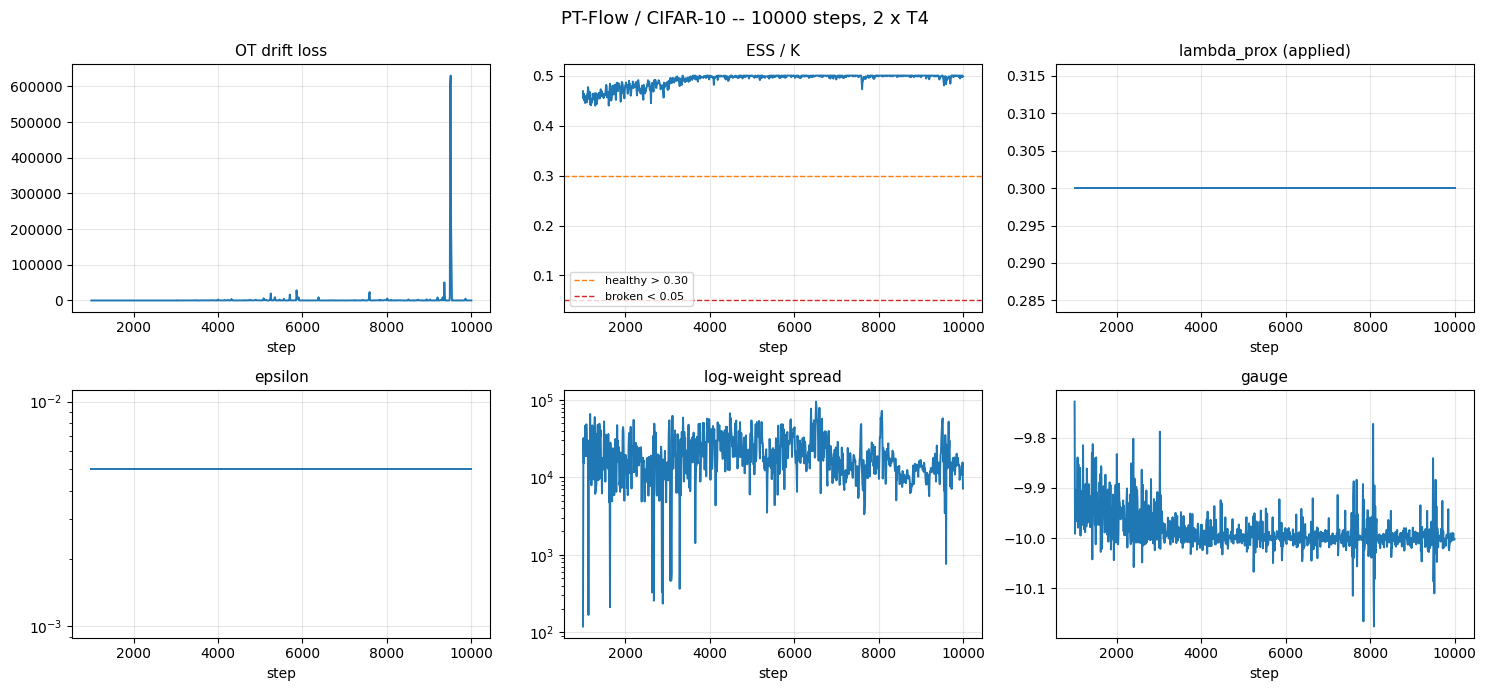

final  step=9999  loss=49.4856
  pt/ess               0.49826
  pt/health            2
  pt/lambda_prox       0.3
  pt/eps               0.005
  pt/logw_spread       7169.4
  pt/clip_frac         0.49826
  pt/gauge             -10.002

healthy: the estimator certified, so the eps anneal and the prox ramp advanced.


In [10]:
import os, json
import matplotlib.pyplot as plt

rows = [json.loads(l) for l in open(os.path.join(RUNDIR, "log", "metrics.jsonl"))]
step = [r["step"] for r in rows]
get  = lambda k: [r.get(k, float("nan")) for r in rows]

panels = [("loss", "OT drift loss", False),
          ("pt/ess", "ESS / K", False),
          ("pt/lambda_prox", "lambda_prox (applied)", False),
          ("pt/eps", "epsilon", True),
          ("pt/logw_spread", "log-weight spread", True),
          ("pt/gauge", "gauge", False)]
panels = [p for p in panels if any(v == v for v in get(p[0]))]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (key, title, logy) in zip(axes.ravel(), panels):
    ax.plot(step, get(key), lw=1.4)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("step")
    ax.grid(alpha=0.3)
    if logy:
        ax.set_yscale("log")
    if key == "pt/ess":
        ax.axhline(0.30, color="tab:orange", ls="--", lw=1, label="healthy > 0.30")
        ax.axhline(0.05, color="tab:red",    ls="--", lw=1, label="broken < 0.05")
        ax.legend(fontsize=8)
for ax in axes.ravel()[len(panels):]:
    ax.axis("off")
fig.suptitle(f"PT-Flow / CIFAR-10 -- {TOTAL_STEPS} steps, {NPROC} x T4", fontsize=13)
fig.tight_layout()
plt.show()

last = rows[-1]
print(f"final  step={last['step']}  loss={last['loss']:.4f}")
for k in ("pt/ess", "pt/health", "pt/lambda_prox", "pt/eps",
          "pt/logw_spread", "pt/clip_frac", "pt/gauge"):
    if k in last:
        print(f"  {k:<20} {last[k]:.5g}")
h = last.get("pt/health")
if h is not None:
    print({2: "\nhealthy: the estimator certified, so the eps anneal and the prox ramp advanced.",
           1: "\ndegrading: anneal frozen, alpha_def raised, lambda_prox decaying. Lower lambda_prox_max.",
           0: "\nbroken: theta frozen and lambda_prox held at 0 -- the run fell back onto the W-Flow arm."
           }.get(int(h), ""))

## [11] Generate images

Three samplers off the one checkpoint, no retraining between them:

- **Mode A** — strict 1-NFE, identical to W-Flow. Needs no potential. This is the
  deployed sampler and the one that matters.
- **Mode B** — n-step prox refinement. Only helps once `pt/prox_resid_rel` has fallen
  below ~0.5; at 1000 steps it will not have, so expect B to look *worse*. That is
  the documented behaviour, not a bug.
- **Mode C** — SNIS. It reweights rather than moves, so it cannot walk samples off
  the manifold; it is the safe extra-NFE mode.

`--cfg-scale` is the generator's conditioning (W-Flow convention: `cfg = w + 1`).
`--pt-w` is the potential's own guidance and is a genuinely different mechanism —
it defaults to `cfg_scale - 1` but is worth sweeping on its own axis.

checkpoint: /kaggle/working/runs/ptflow_cifar10/checkpoints/state_00010000.pt
--- A ------------------------------------------------------------
Loaded EMA model from step 10000 (/kaggle/working/runs/ptflow_cifar10/checkpoints/state_00010000.pt)
  Parameters: 22,881,548
Saved 10x8 grid (80 images) to /kaggle/working/samples/grid_A.png
--- B ------------------------------------------------------------
Loaded EMA model from step 10000 (/kaggle/working/runs/ptflow_cifar10/checkpoints/state_00010000.pt)
  Parameters: 22,881,548
  Potential: 7,509,892 params, scale net: 1,026,956, eps=0.005
Saved 10x8 grid (80 images) to /kaggle/working/samples/grid_B.png
--- C ------------------------------------------------------------
Loaded EMA model from step 10000 (/kaggle/working/runs/ptflow_cifar10/checkpoints/state_00010000.pt)
  Parameters: 22,881,548
  Potential: 7,509,892 params, scale net: 1,026,956, eps=0.005
Saved 10x8 grid (80 images) to /kaggle/working/samples/grid_C.png

### A (1-NFE, depl

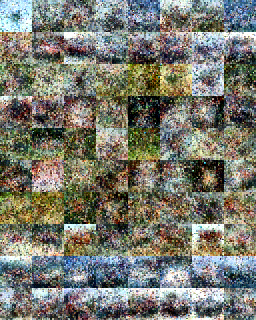


### B (4-step prox refine)   -- rows are classes 0..9: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck


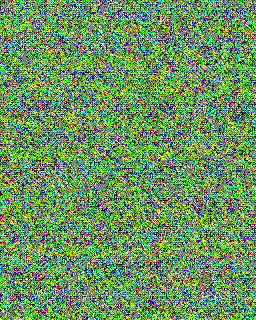


### C (SNIS, K=16)   -- rows are classes 0..9: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck


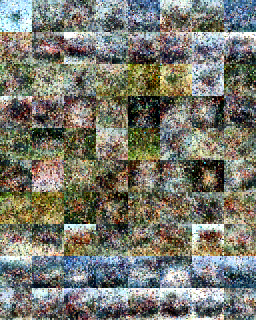

In [11]:
import os, sys, glob, subprocess
from IPython.display import Image as IPyImage, display

CKPT = sorted(glob.glob(os.path.join(RUNDIR, "checkpoints", "state_*.pt")))[-1]
OUT  = "/kaggle/working/samples"
os.makedirs(OUT, exist_ok=True)
print("checkpoint:", CKPT)

env = dict(os.environ)
env.update(DRIFT_COMPILE="0", PYTHONPATH=WORK, CUDA_VISIBLE_DEVICES="0")

# 10 rows (one per CIFAR class) x 8 columns
CLASS_IDS = ",".join(str(c) for c in range(NUM_CLASSES) for _ in range(8))

def sample(tag, extra, cfg_scale=1.5):
    path = os.path.join(OUT, f"grid_{tag}.png")
    cmd = [sys.executable, "inference_ours.py", "sample",
           "--ckpt", CKPT, "--config", CFG_PATH,
           "--cfg-scale", str(cfg_scale), "--seed", "0",
           "--class-ids", CLASS_IDS, "--num-rows", str(NUM_CLASSES),
           "--save-path", path, "--workdir", os.path.join(OUT, "_wd")] + extra
    r = subprocess.run(cmd, cwd=WORK, env=env, capture_output=True, text=True)
    print(f"--- {tag} " + "-" * 60)
    print(r.stdout.strip() or r.stderr.strip()[-1200:])
    return path if r.returncode == 0 else None

paths = {"A (1-NFE, deployed)": sample("A", ["--sampler", "A"])}
if PT_ENABLED:
    paths["B (4-step prox refine)"] = sample(
        "B", ["--sampler", "B", "--refine-steps", "4", "--refine-gamma", "0.5"])
    paths["C (SNIS, K=16)"] = sample("C", ["--sampler", "C", "--snis-k", "16"])

for name, p in paths.items():
    if p and os.path.exists(p):
        print(f"\n### {name}   -- rows are classes 0..9: {', '.join(CIFAR_NAMES)}")
        display(IPyImage(filename=p))

### Labelled grid, and a `cfg_scale` sweep (Mode A)

Loaded EMA model from step 10000 (/kaggle/working/runs/ptflow_cifar10/checkpoints/state_00010000.pt)
  Parameters: 22,881,548


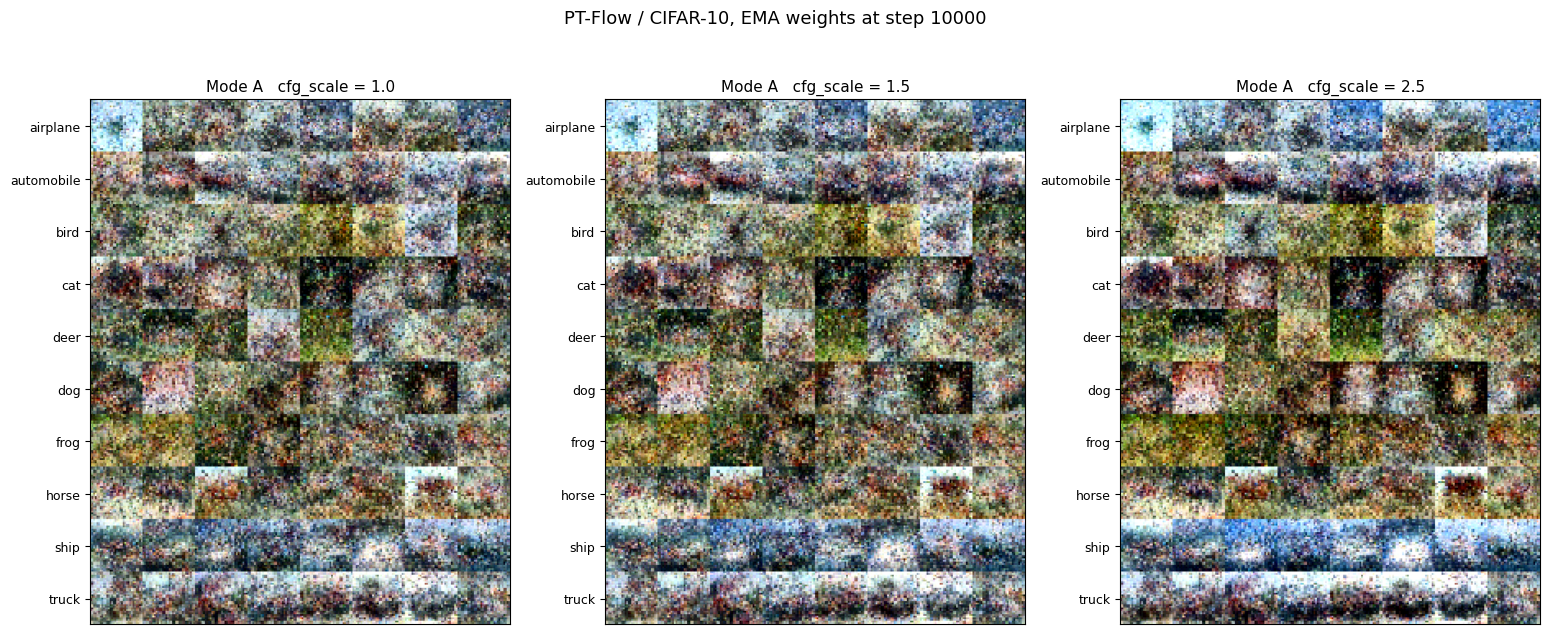


1000 steps of a raw-pixel drift loss produces colour statistics, not objects.
The claim this run supports is that the pipeline trains and samples; the ESS /
lambda_prox / eps traces in cell [10] are the actual evidence for it.


In [12]:
import os, sys, numpy as np, torch, matplotlib.pyplot as plt

if WORK not in sys.path:
    sys.path.insert(0, WORK)
os.chdir(WORK)
os.environ["DRIFT_COMPILE"] = "0"

from inference_ours import _load_model, make_sampler

model, postprocess_fn, ckpt_step, device, potential, scale_net, eps = _load_model(
    CKPT, CFG_PATH, want_potential=False)

@torch.no_grad()
def grid(cfg_scale, per_class=8, seed=0):
    labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(per_class)
    rng = torch.Generator(device=device)
    rng.manual_seed(seed)
    x = make_sampler(model, None, None, mode="A", cfg_scale=cfg_scale)(labels, rng)
    img = postprocess_fn(x).float().cpu().numpy().transpose(0, 2, 3, 1)
    return np.clip(img, 0, 1).reshape(NUM_CLASSES, per_class, 32, 32, 3)

SWEEP = [1.0, 1.5, 2.5]
fig, axes = plt.subplots(1, len(SWEEP), figsize=(5.2 * len(SWEEP), 7.0))
for ax, cs in zip(np.atleast_1d(axes), SWEEP):
    g = grid(cs)
    canvas = g.transpose(0, 2, 1, 3, 4).reshape(NUM_CLASSES * 32, g.shape[1] * 32, 3)
    ax.imshow(canvas)
    ax.set_xticks([])
    ax.set_yticks(np.arange(NUM_CLASSES) * 32 + 16)
    ax.set_yticklabels(CIFAR_NAMES, fontsize=9)
    ax.set_title(f"Mode A   cfg_scale = {cs}", fontsize=11)
fig.suptitle(f"PT-Flow / CIFAR-10, EMA weights at step {ckpt_step}", fontsize=13)
fig.tight_layout()
fig.savefig("/kaggle/working/samples/grid_labelled.png", dpi=130)
plt.show()

print("\n1000 steps of a raw-pixel drift loss produces colour statistics, not objects.")
print("The claim this run supports is that the pipeline trains and samples; the ESS /")
print("lambda_prox / eps traces in cell [10] are the actual evidence for it.")

## [12] What you have, and how to continue

In [13]:
import os, glob, shutil, torch

FINAL = "/kaggle/working/ptflow_cifar10_output"
os.makedirs(FINAL, exist_ok=True)

ck = sorted(glob.glob(os.path.join(RUNDIR, "checkpoints", "state_*.pt")))[-1]
shutil.copy2(ck, os.path.join(FINAL, os.path.basename(ck)))
shutil.copy2(CFG_PATH, os.path.join(FINAL, "config.yaml"))
shutil.copy2(os.path.join(RUNDIR, "log", "metrics.jsonl"), os.path.join(FINAL, "metrics.jsonl"))
for p in glob.glob("/kaggle/working/samples/grid_*.png"):
    shutil.copy2(p, FINAL)
ema = os.path.join(RUNDIR, "params_ema")
if os.path.isdir(ema):
    shutil.copytree(ema, os.path.join(FINAL, "params_ema"), dirs_exist_ok=True)

print(FINAL)
for f in sorted(os.listdir(FINAL)):
    p = os.path.join(FINAL, f)
    sz = (os.path.getsize(p) if os.path.isfile(p)
          else sum(os.path.getsize(os.path.join(p, x)) for x in os.listdir(p)))
    print(f"  {f:<34} {sz / 2**20:8.1f} MiB")

payload = torch.load(ck, map_location="cpu", weights_only=False)
print("\ncheckpoint keys:", sorted(payload.keys()))
print("step:", payload["step"])
print("""
  model / ema_model are W-Flow-shaped, so this file also loads into stock W-Flow.
  pt_model / pt_ema_model / pt_scale_model / pt_schedule are the PT-Flow side.

To continue training: raise TOTAL_STEPS in cell [1], then re-run cells [6], [7] and [9].
restore_checkpoint() picks up the last state_*.pt in RUNDIR/checkpoints and restores
the schedule too -- eps_progress and prox_progress advance only on healthy steps, so
replaying them from zero would reheat the bridge and re-warm a ramp already earned.

Save the notebook output as a Kaggle Dataset to carry the checkpoint to the next run.
""")

/kaggle/working/ptflow_cifar10_output
  config.yaml                             0.0 MiB
  grid_A.png                              0.2 MiB
  grid_B.png                              0.2 MiB
  grid_C.png                              0.2 MiB
  grid_labelled.png                       2.5 MiB
  metrics.jsonl                           1.1 MiB
  params_ema                             87.3 MiB
  state_00010000.pt                     479.9 MiB

checkpoint keys: ['ema_decay', 'ema_model', 'model', 'optimizer', 'pt_ema_model', 'pt_ema_scale_model', 'pt_model', 'pt_optimizer', 'pt_scale_model', 'pt_schedule', 'step']
step: 10000

  model / ema_model are W-Flow-shaped, so this file also loads into stock W-Flow.
  pt_model / pt_ema_model / pt_scale_model / pt_schedule are the PT-Flow side.

To continue training: raise TOTAL_STEPS in cell [1], then re-run cells [6], [7] and [9].
restore_checkpoint() picks up the last state_*.pt in RUNDIR/checkpoints and restores
the schedule too -- eps_progress and pr